In [1]:
!pip install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 102.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 20.5 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T
import numpy as np
import requests
import os
import urllib.request
import matplotlib.pyplot as plt

# --- 1. 全域配置與資料下載 ---
# 擴展至 20 個類別
CLASSES = [
    'airplane', 'apple', 'banana', 'bicycle', 'bird',
    'bus', 'camera', 'cat', 'chair', 'door',
    'eye', 'flashlight', 'guitar', 'hat', 'helmet',
    'ice cream', 'jacket', 'mountain', 'star', 'umbrella'
]
CLASSES = sorted(CLASSES)

MAX_ITEMS_PER_CLASS = 15000 # 樣本數增加到 15,000
IMG_SIZE = 64
BATCH_SIZE = 64
EPOCHS = 100
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 建立資料夾並下載資料
os.makedirs('data', exist_ok=True)
base_url = 'https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/'

print(f"正在準備 {len(CLASSES)} 個類別: {CLASSES}")
for cls in CLASSES:
    path = f'data/{cls}.npy'
    if not os.path.exists(path):
        cls_url = cls.replace(' ', '%20')
        url = f"{base_url}{cls_url}.npy"
        try:
            urllib.request.urlretrieve(url, path)
        except Exception as e:
            print(f"下載 {cls} 失敗: {e}")

print(f"優化配置：類別數={len(CLASSES)}, 每類樣本={MAX_ITEMS_PER_CLASS}")

正在準備 20 個類別: ['airplane', 'apple', 'banana', 'bicycle', 'bird', 'bus', 'camera', 'cat', 'chair', 'door', 'eye', 'flashlight', 'guitar', 'hat', 'helmet', 'ice cream', 'jacket', 'mountain', 'star', 'umbrella']
優化配置：類別數=20, 每類樣本=15000


In [3]:
import torch.nn.functional as F

# --- 2.1 強化數據增強：提升推理與泛化能力 ---
train_transform = T.Compose([
    T.RandomRotation(15),
    T.RandomAffine(degrees=0, translate=(0.2, 0.2), scale=(0.7, 1.3)),
    T.RandomHorizontalFlip(),
])

class QuickDrawDataset(Dataset):
    def __init__(self, classes, max_items_per_class, transform=None):
        self.X = []
        self.y = []
        self.transform = transform
        for idx, cls in enumerate(classes):
            path = f'data/{cls}.npy'
            if os.path.exists(path):
                data = np.load(path)[:max_items_per_class]
                self.X.append(data)
                self.y.append(np.full(len(data), idx))
        self.X = np.concatenate(self.X).reshape(-1, 1, 28, 28).astype(np.float32) / 255.0
        self.y = np.concatenate(self.y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])
        if self.transform:
            x = self.transform(x)
        return x, torch.tensor(self.y[idx], dtype=torch.long)

In [4]:
# --- 3. 初始化 10 類別資料集 ---
print(f"正在初始化資料集: {CLASSES}")

full_dataset = QuickDrawDataset(CLASSES, MAX_ITEMS_PER_CLASS, transform=train_transform)

indices = list(range(len(full_dataset)))
np.random.shuffle(indices)
split = int(0.9 * len(indices))

train_loader = DataLoader(Subset(full_dataset, indices[:split]), batch_size=BATCH_SIZE, shuffle=True)

val_dataset_no_aug = QuickDrawDataset(CLASSES, MAX_ITEMS_PER_CLASS, transform=None)
val_loader = DataLoader(Subset(val_dataset_no_aug, indices[split:]), batch_size=BATCH_SIZE, shuffle=False)

print(f"資料集建立完成。總樣本數: {len(full_dataset)}, 訓練集: {len(train_loader.dataset)}, 驗證集: {len(val_loader.dataset)}")

正在初始化資料集: ['airplane', 'apple', 'banana', 'bicycle', 'bird', 'bus', 'camera', 'cat', 'chair', 'door', 'eye', 'flashlight', 'guitar', 'hat', 'helmet', 'ice cream', 'jacket', 'mountain', 'star', 'umbrella']
資料集建立完成。總樣本數: 300000, 訓練集: 270000, 驗證集: 30000


In [5]:
import torchvision.models as models

class QuickMobileNetV2(nn.Module):
    def __init__(self, num_classes):
        super(QuickMobileNetV2, self).__init__()
        # 載入預訓練或基礎 MobileNetV2 結構
        # 因為 QuickDraw 是單通道 (1, 28, 28)，我們需要修改第一層
        self.model = models.mobilenet_v2(num_classes=num_classes)
        self.model.features[0][0] = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)

    def forward(self, x):
        # MobileNetV2 通常期望較大的輸入，但對於 28x28，我們可以透過調整 features 來直接處理
        return self.model(x)

model = QuickMobileNetV2(len(CLASSES)).to(DEVICE)
print("已成功更換為 MobileNetV2 架構，針對輕量推理進行優化。")

已成功更換為 MobileNetV2 架構，針對輕量推理進行優化。


In [6]:
import time

# --- 5. 最佳化訓練流程 (MobileNetV2 + Early Stopping) ---
full_dataset = QuickDrawDataset(CLASSES, MAX_ITEMS_PER_CLASS, transform=train_transform)
val_dataset_no_aug = QuickDrawDataset(CLASSES, MAX_ITEMS_PER_CLASS, transform=None)
indices = list(range(len(full_dataset)))
np.random.shuffle(indices)
split = int(0.9 * len(indices))

train_loader = DataLoader(Subset(full_dataset, indices[:split]), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(Subset(val_dataset_no_aug, indices[split:]), batch_size=BATCH_SIZE, shuffle=False)

model = QuickMobileNetV2(len(CLASSES)).to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.05)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=4e-3, steps_per_epoch=len(train_loader), epochs=EPOCHS)

# 訓練參數記錄
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0
best_val_loss = float('inf')
patience = 10
counter = 0
min_acc_delta = 0.1  # 準確率提升閾值
min_loss_delta = 0.001 # 損失下降閾值

print(f"開始執行 MobileNetV2 優化訓練 (Early Stopping Patience: {patience})...")
print(f"監控條件: val_loss 下降 > {min_loss_delta} 或 val_acc 提升 > {min_acc_delta}%")
print("-" * 80)

for epoch in range(EPOCHS):
    start_time = time.time()
    model.train()
    train_loss, train_correct = 0.0, 0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == lbls).sum().item()

    # 驗證階段
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            outputs = model(imgs)
            val_loss += criterion(outputs, lbls).item()
            val_correct += (outputs.argmax(1) == lbls).sum().item()

    # 計算指標
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_acc = 100 * train_correct / len(train_loader.dataset)
    val_acc = 100 * val_correct / len(val_loader.dataset)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    duration = time.time() - start_time
    print(f'Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Time: {duration:.1f}s')

    # 強化版 Early Stopping 邏輯
    improved_acc = val_acc > (best_val_acc + min_acc_delta)
    improved_loss = avg_val_loss < (best_val_loss - min_loss_delta)

    if improved_acc or improved_loss:
        if val_acc > best_val_acc:
            best_val_acc = val_acc
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss

        torch.save(model.state_dict(), 'quickdraw_10_classes.pt')
        counter = 0
        print(f"---> 偵測到改善！模型已儲存 (Best Acc: {best_val_acc:.2f}%, Best Loss: {best_val_loss:.4f})")
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping 觸發於 Epoch {epoch+1}，最佳準確率: {best_val_acc:.2f}%，最佳損失: {best_val_loss:.4f}")
            break


開始執行 MobileNetV2 優化訓練 (Early Stopping Patience: 10)...
監控條件: val_loss 下降 > 0.001 或 val_acc 提升 > 0.1%
--------------------------------------------------------------------------------
Epoch 01/100 | Train Loss: 2.3233 | Val Loss: 1.3369 | Train Acc: 32.91% | Val Acc: 72.96% | Time: 332.9s
---> 偵測到改善！模型已儲存 (Best Acc: 72.96%, Best Loss: 1.3369)
Epoch 02/100 | Train Loss: 1.4485 | Val Loss: 1.0672 | Train Acc: 67.98% | Val Acc: 83.12% | Time: 323.3s
---> 偵測到改善！模型已儲存 (Best Acc: 83.12%, Best Loss: 1.0672)
Epoch 03/100 | Train Loss: 1.2345 | Val Loss: 0.9634 | Train Acc: 76.64% | Val Acc: 87.13% | Time: 324.6s
---> 偵測到改善！模型已儲存 (Best Acc: 87.13%, Best Loss: 0.9634)
Epoch 04/100 | Train Loss: 1.1402 | Val Loss: 0.9274 | Train Acc: 80.36% | Val Acc: 88.64% | Time: 326.2s
---> 偵測到改善！模型已儲存 (Best Acc: 88.64%, Best Loss: 0.9274)
Epoch 05/100 | Train Loss: 1.0901 | Val Loss: 0.8971 | Train Acc: 82.31% | Val Acc: 89.58% | Time: 329.9s
---> 偵測到改善！模型已儲存 (Best Acc: 89.58%, Best Loss: 0.8971)
Epoch 06/100 

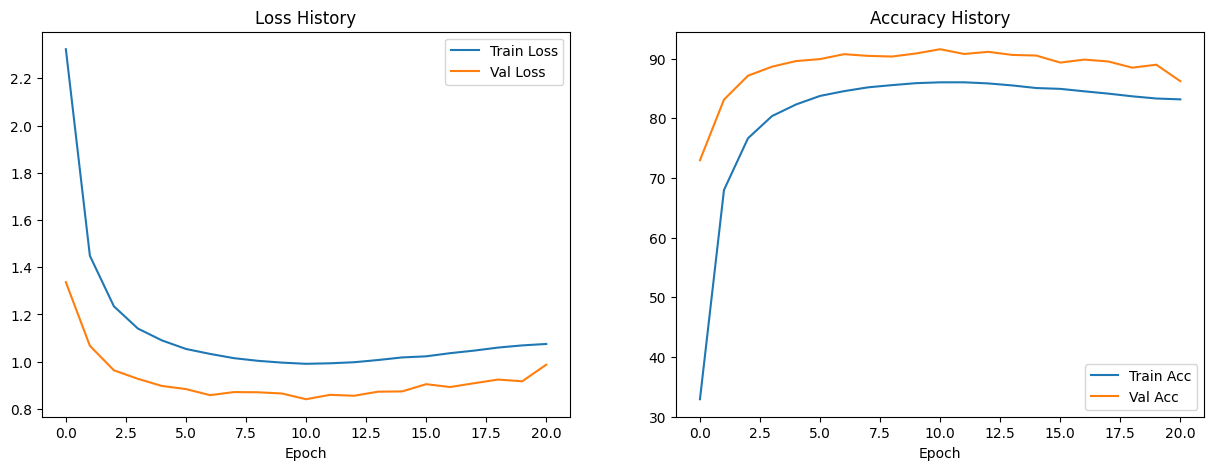

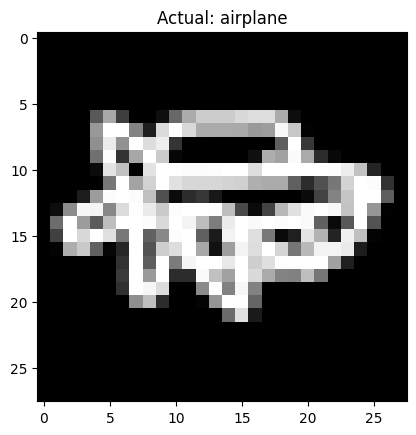

1. airplane: 47.69%
2. star: 9.02%
3. bird: 7.91%


In [7]:
# --- 6. 結果測試與詳細視覺化 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss 圖表
ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_title('Loss History')
ax1.set_xlabel('Epoch')
ax1.legend()

# Accuracy 圖表
ax2.plot(history['train_acc'], label='Train Acc')
ax2.plot(history['val_acc'], label='Val Acc')
ax2.set_title('Accuracy History')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.show()

def predict_random():
    if os.path.exists('quickdraw_10_classes.pt'):
        model.load_state_dict(torch.load('quickdraw_10_classes.pt'))
    model.eval()
    img, lbl = val_loader.dataset[np.random.randint(len(val_loader.dataset))]
    out = model(img.unsqueeze(0).to(DEVICE))
    probs = torch.softmax(out, 1)
    val, idx = torch.topk(probs, 3)

    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f'Actual: {CLASSES[lbl]}')
    plt.show()
    for i in range(3):
        print(f"{i+1}. {CLASSES[idx[0][i]]}: {val[0][i].item()*100:.2f}%")

predict_random()

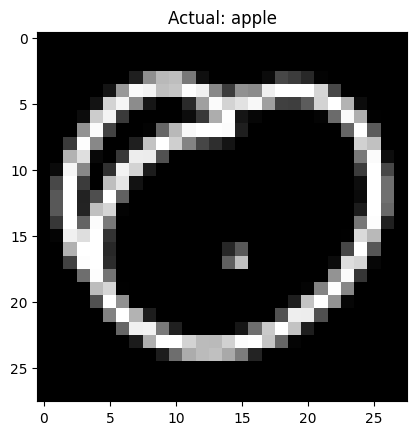

Top-3 Predictions:
1. helmet: 69.20%
2. apple: 13.33%
3. hat: 2.04%


In [8]:
def test_random_image():
    model.eval()
    # 使用 val_loader.dataset 代替未定義的 val_dataset
    idx = np.random.randint(len(val_loader.dataset))
    image, label = val_loader.dataset[idx]

    with torch.no_grad():
        output = model(image.unsqueeze(0).to(DEVICE))
        probs = torch.nn.functional.softmax(output, dim=1)
        top3_prob, top3_idx = torch.topk(probs, 3)

    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(f'Actual: {CLASSES[label]}')
    plt.show()

    print("Top-3 Predictions:")
    for i in range(3):
        print(f"{i+1}. {CLASSES[top3_idx[0][i]]}: {top3_prob[0][i].item()*100:.2f}%")

test_random_image()

In [9]:
# --- 7. 儲存類別標籤 ---
with open('labels.txt', 'w') as f:
    for cls in CLASSES:
        f.write(f"{cls}\n")

print(f"已將選定的 {len(CLASSES)} 個類別名稱存入 labels.txt")

已將選定的 20 個類別名稱存入 labels.txt
